<a href="https://colab.research.google.com/github/Aditi-1612/30-days-of-code-tcp-2026/blob/main/CDCGAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
print(f"PyTorch version: {torch.__version__}")
cuda_available=torch.cuda.is_available()
print(f"id gpu available: {cuda_available}")
if cuda_available:
  print(f"GPU Name:{torch.cuda.get_device_name(0)}")

PyTorch version: 2.9.0+cu126
id gpu available: True
GPU Name:Tesla T4


In [ ]:
import os
import random
import torch
import numpy as np
import cv2
import torch.nn as nn
import torch.optim as optim
import torch.utils.data
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML,display
from tqdm.notebook import tqdm
import torchvision.utils as vutils

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Hyperparameters
dataroot = "/content/cifar10"
workers = 2
batch_size = 128
image_size = 32
nc = 3
nz = 100
ngf = 64
ndf = 64
num_epochs = 50
num_classes = 10
lr = 0.0002
beta1 = 0.5
beta2 = 0.999
ngpu = 1
manualSeed = 999


print(f"Random Seed: {manualSeed}")
random.seed(manualSeed)
torch.manual_seed(manualSeed)
torch.cuda.manual_seed_all(manualSeed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Random Seed: 999
Using device: cpu


In [ ]:
# CIFAR-10 classes
CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
 'dog', 'frog', 'horse', 'ship', 'truck']

# Normalize images to [-1, 1] for Tanh output
transform = transforms.Compose([
 transforms.ToTensor(),
 transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load CIFAR-10
train_set = datasets.CIFAR10(root='./data', train=True,
 transform=transform, download=True)
test_set=datasets.CIFAR10(root='./data', train=False,
 transform=transform, download=True)

from torch.utils.data import DataLoader

train_loader = DataLoader(train_set, batch_size=batch_size,
 shuffle=True, num_workers=2)
test_loader = DataLoader(test_set, batch_size=batch_size,
 shuffle=False, num_workers=2)

print(f"data loaded. Training batches: {len(train_loader)}")

100%|██████████| 170M/170M [00:02<00:00, 57.3MB/s]


data loaded. Training batches: 391


In [ ]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [ ]:

class ConditionalDCGANGenerator(nn.Module):
    def __init__(self, latent_dim, num_classes, img_size=32, channels=3, ngf=64):
        super().__init__()
        self.label_embedding = nn.Embedding(num_classes, latent_dim)

        self.main = nn.Sequential(
            # Input: (latent_dim + latent_dim) x 1 x 1
            nn.ConvTranspose2d(latent_dim * 2, ngf * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # State size: (ngf*4) x 4 x 4
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # State size: (ngf*2) x 8 x 8
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # State size: (ngf) x 16 x 16
            nn.ConvTranspose2d(ngf, channels, 4, 2, 1, bias=False),
            nn.Tanh()
            # State size: (channels) x 32 x 32
        )

    def forward(self, noise, labels):
        # Concatenate label embedding and noise
        label_embedding = self.label_embedding(labels) # Shape: (batch_size, latent_dim)
        # Reshape label_embedding to (batch_size, latent_dim, 1, 1) to match noise dimensions
        label_embedding_expanded = label_embedding.unsqueeze(2).unsqueeze(3)
        gen_input = torch.cat((label_embedding_expanded, noise), dim=1)
        # The next line is no longer necessary as gen_input is already 4D with correct dimensions
        # gen_input = gen_input.view(gen_input.size(0), -1, 1, 1)
        return self.main(gen_input)

class ConditionalDCGANDiscriminator(nn.Module):
    def __init__(self, num_classes, img_size=32, channels=3, ndf=64):
        super().__init__()
        self.label_embedding = nn.Embedding(num_classes, 1)
        self.img_size = img_size

        self.main = nn.Sequential(
            # Input: (channels + 1) x 32 x 32
            nn.Conv2d(channels + 1, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # State size: (ndf) x 16 x 16
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # State size: (ndf*2) x 8 x 8
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # State size: (ndf*4) x 4 x 4
            nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        # Create a label map by expanding the embedded label
        embedded_label = self.label_embedding(labels).view(labels.size(0), 1, 1, 1)
        label_map = embedded_label.expand(labels.size(0), 1, self.img_size, self.img_size)
        d_input = torch.cat((img, label_map), dim=1)
        return self.main(d_input).view(-1, 1).squeeze(1)

# Instantiate the models
generator = ConditionalDCGANGenerator(
    latent_dim=nz,
    num_classes=num_classes,
    img_size=image_size,
    channels=nc,
    ngf=ngf
).to(device)

discriminator = ConditionalDCGANDiscriminator(
    num_classes=num_classes,
    img_size=image_size,
    channels=nc,
    ndf=ndf
).to(device)

print("ConditionalDCGANGenerator and ConditionalDCGANDiscriminator models defined and instantiated.")

ConditionalDCGANGenerator and ConditionalDCGANDiscriminator models defined and instantiated.


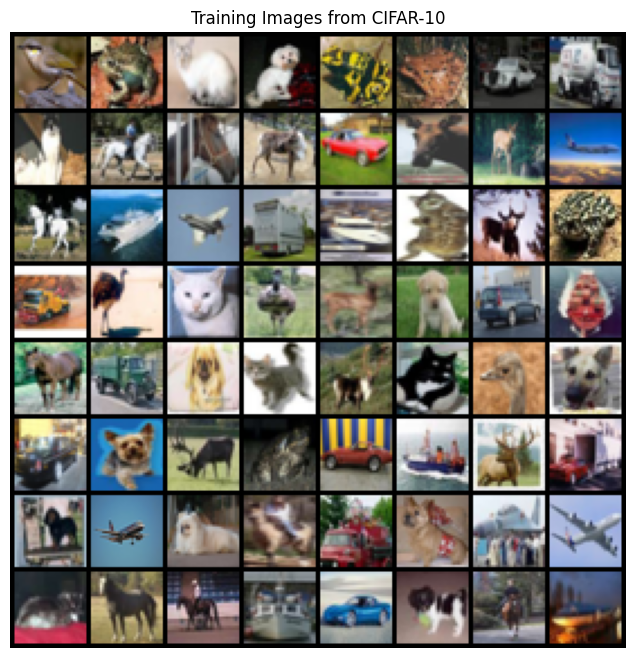

In [ ]:
real_batch = next(iter(train_loader))
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Training Images from CIFAR-10")
plt.imshow(np.transpose (vutils.make_grid(real_batch[0][:64], padding=2, normalize=True).cpu(), (1, 2, 0)))
plt.show()

criterion = nn.BCELoss()
optimizer_g = optim.Adam(
 generator.parameters(),
 lr=lr, betas=(beta1, beta2)
)
optimizer_d = optim.Adam(
 discriminator.parameters(),
 lr=lr, betas=(beta1, beta2)
)

In [ ]:
image_list=[]
g_losses = []
d_losses = []
# Iters=0 # Removed as it was not used
print("Starting Training Loop...")

# Create fixed noise and labels for visualizing generator progress
fixed_noise = torch.randn(64, nz, 1, 1, device=device)
fixed_labels = torch.randint(0, num_classes, (64,), device=device)

for epoch in range(num_epochs):
    Pbar=tqdm(enumerate(train_loader), total=len(train_loader), desc=f'Epoch {epoch+1}/{num_epochs}')
    for batch_idx, (images, labels) in enumerate(train_loader):
      images = images.to(device)
      labels = labels.to(device)
      current_batch_size = images.size(0)

      real_labels = torch.ones(current_batch_size).to(device)
      fake_labels = torch.zeros(current_batch_size).to(device)

        # ===== TRAIN DISCRIMINATOR =====
      optimizer_d.zero_grad()

        # Real images with their correct labels
      d_real = discriminator(images, labels)
      loss_d_real = criterion(d_real, real_labels)

        # Fake images with sampled labels
      z = torch.randn(current_batch_size, nz, 1, 1).to(device) # Corrected: Reshape noise to 4D
      fake_labels_sample = torch.randint(
       0, num_classes, (current_batch_size,)).to(device)

      fake_images = generator(z, fake_labels_sample)
      d_fake = discriminator(fake_images.detach(), fake_labels_sample)
      loss_d_fake = criterion(d_fake, fake_labels) # Corrected: Removed extra 'fake' argument

      loss_d = loss_d_real + loss_d_fake
      loss_d.backward()
      optimizer_d.step()

        # ===== TRAIN GENERATOR =====
      optimizer_g.zero_grad()

      z = torch.randn(current_batch_size, nz, 1, 1).to(device) # Corrected: Reshape noise to 4D
      fake_labels_sample = torch.randint(
        0, num_classes, (current_batch_size,)).to(device)

      fake_images = generator(z, fake_labels_sample)
      output_gen = discriminator(fake_images, fake_labels_sample) # Renamed to output_gen for clarity
      loss_g = criterion(output_gen, real_labels) # Generator tries to fool discriminator into thinking fakes are real
      loss_g.backward()
      D_G_z2 = output_gen.mean().item()
      optimizer_g.step()

      g_losses.append(loss_g.item()) # Corrected: Use loss_g
      d_losses.append(loss_d.item()) # Corrected: Use loss_d

      Pbar.set_postfix({
            'Loss_D': f'{loss_d.item():.4f}', # Corrected: Use loss_d
            'Loss_G': f'{loss_g.item():.4f}', # Corrected: Use loss_g
        })
        # Iters += 1 # Removed as it was not used

      if batch_idx % 50 == 0: # Corrected: Use batch_idx instead of i
            print(f"Epoch [{epoch+1}/{num_epochs}] Batch [{batch_idx}] "
                  f"D_loss: {loss_d.item():.4f} G_loss: {loss_g.item():.4f}") # Corrected: Use loss_d, loss_g, batch_idx

    # Save models and visualize generated images every 05 epochs
    if (epoch + 1) % 5 == 0:
        with torch.no_grad():
            fake = generator(fixed_noise, fixed_labels).detach().cpu()
        image_list.append(vutils.make_grid(fake, padding=2, normalize=True))

        plt.figure(figsize=(8, 8))
        plt.axis("off")
        plt.title(f"generated images - Epoch {epoch+1}")
        plt.imshow(np.transpose(image_list[-1], (1, 2, 0)))
        plt.show()

        #specific classes

generator.eval()
with torch.no_grad():
 # Generate images for each class
 for class_idx, class_name in enumerate(CLASSES):
  z = torch.randn(16, nz, 1, 1).to(device) # Corrected: Reshape noise to 4D
  labels = torch.full((16,), class_idx).to(device)

  fake_images = generator(z, labels)

  print(f"Generated {class_name}s successfully!")


Starting Training Loop...


Epoch 1/50:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch [1/50] Batch [0] D_loss: 1.4151 G_loss: 1.3532
Epoch [1/50] Batch [50] D_loss: 1.0297 G_loss: 2.0515
Epoch [1/50] Batch [100] D_loss: 0.9003 G_loss: 1.8823
Epoch [1/50] Batch [150] D_loss: 0.9435 G_loss: 1.4217
Epoch [1/50] Batch [200] D_loss: 1.0370 G_loss: 1.3962
Epoch [1/50] Batch [250] D_loss: 1.0734 G_loss: 1.6710
Epoch [1/50] Batch [300] D_loss: 0.9202 G_loss: 1.6399
Epoch [1/50] Batch [350] D_loss: 0.7121 G_loss: 2.3191


Epoch 2/50:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch [2/50] Batch [0] D_loss: 0.8998 G_loss: 1.5922
Epoch [2/50] Batch [50] D_loss: 0.9091 G_loss: 2.6715
Epoch [2/50] Batch [100] D_loss: 0.6922 G_loss: 2.3042
Epoch [2/50] Batch [150] D_loss: 0.9984 G_loss: 2.4012
Epoch [2/50] Batch [200] D_loss: 1.0674 G_loss: 2.8503
Epoch [2/50] Batch [250] D_loss: 0.7136 G_loss: 2.7105
Epoch [2/50] Batch [300] D_loss: 0.7779 G_loss: 2.5340
Epoch [2/50] Batch [350] D_loss: 0.7705 G_loss: 1.8907


Epoch 3/50:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch [3/50] Batch [0] D_loss: 0.5950 G_loss: 1.5834
Epoch [3/50] Batch [50] D_loss: 0.6389 G_loss: 2.3233
Epoch [3/50] Batch [100] D_loss: 0.7023 G_loss: 2.5857
Epoch [3/50] Batch [150] D_loss: 0.6880 G_loss: 2.0379
Epoch [3/50] Batch [200] D_loss: 0.8608 G_loss: 2.0801
Epoch [3/50] Batch [250] D_loss: 0.6857 G_loss: 2.1518
Epoch [3/50] Batch [300] D_loss: 0.7638 G_loss: 2.9421
Epoch [3/50] Batch [350] D_loss: 0.7072 G_loss: 3.3894


KeyboardInterrupt: 